# Network optimization with integer programming

by Javier Fernández Ramos

## Delivery route optimization for a small logistics company

In this notebook we are going to explore a classic problem in combinatorial and network optimization, an optimal routing problem calculation, also known as the Traveling Salesman Problem.

The goal of this implementation is to find the shortest possible route that visits each delivery location once and returns to the starting point, the depot.

### Real world motivation

In a logistics company, optimizing delivery routes can significantly reduce fuel costs, improve delivery times, and enhance customer satisfaction. By minimizing the total distance traveled, the company can also reduce its carbon footprint.

### Data Setup

We are going to simulate a little scenario with eight delivery locations plus a depot, that will be our starting and returning point.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

Delivery Locations (with coordinates):


,Location,x,y
0,L0,51,74
1,L1,92,87
2,L2,14,99
3,L3,71,23
4,L4,60,2
5,L5,20,21
6,L6,82,52
7,L7,86,1
8,L8,74,87


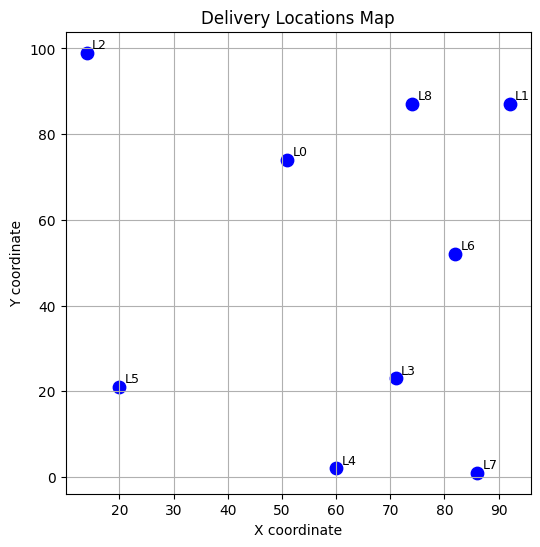

Distance Matrix:


Location,L0,L1,L2,L3,L4,L5,L6,L7,L8
Location,,,,,,,,,
L0,0.00,43.01,44.65,54.78,72.56,61.40,38.01,80.96,26.42
L1,43.01,0.00,78.92,67.36,90.82,97.67,36.40,86.21,18.00
L2,44.65,78.92,0.00,95.00,107.35,78.23,82.66,121.61,61.19
L3,54.78,67.36,95.00,0.00,23.71,51.04,31.02,26.63,64.07
L4,72.56,90.82,107.35,23.71,0.00,44.28,54.63,26.02,86.15
L5,61.40,97.67,78.23,51.04,44.28,0.00,69.32,68.96,85.28
L6,38.01,36.40,82.66,31.02,54.63,69.32,0.00,51.16,35.90
L7,80.96,86.21,121.61,26.63,26.02,68.96,51.16,0.00,86.83
L8,26.42,18.00,61.19,64.07,86.15,85.28,35.90,86.83,0.00


In [2]:
# Set random seed for reproducibility
np.random.seed(42)

num_locations = 8
locations = pd.DataFrame({
    'Location': [f'L{i}' for i in range(num_locations + 1)],  # L0 will be the depot
    'x': np.random.randint(0, 100, size=num_locations + 1),
    'y': np.random.randint(0, 100, size=num_locations + 1)
})
# After generating the random coordinates using numpy random, we store them into a dataframe, locations. The depot's location is also randomly generated

print("Delivery Locations (with coordinates):")
display(locations)

# Plot a grid map of locations
plt.figure(figsize=(6, 6))
plt.scatter(locations['x'], locations['y'], c='blue', s=80)
for i, row in locations.iterrows():
    plt.text(row['x'] + 1, row['y'] + 1, row['Location'], fontsize=9)
plt.title("Delivery Locations Map")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid(True)
plt.show()

# Compute distance between the different locations using Euclidean distance between the x and y coordinates.
def euclidean_distance(p1, p2):
    return np.sqrt((p1['x'] - p2['x'])**2 + (p1['y'] - p2['y'])**2)

# Create a distance matrix that store this distances between each pair of locations.
dist_matrix = pd.DataFrame(
    [[euclidean_distance(p1, p2) for _, p2 in locations.iterrows()] for _, p1 in locations.iterrows()],
    columns=locations['Location'],
    index=locations['Location']
)

print("Distance Matrix:")
display(dist_matrix.round(2))

- L0 will be our depot.
- Ln will be the different delivery locations

We can see in the map grid the different locations generated. This a simulated small scenario where we gave simulated altitudes and latitudes for our delivery locations and the calculated distance between them is really the euclidean difference between these simulated coordinates.

This approach is difficult to see through a real life scenario as it could be seen but this implementation could be generalized or the base to solve a larger problem.

### PuLP library

PuLP is a linear and mixed integer programming modeler libray in Python. With PuLP, it is simple to create MILP optimisation problems and solve them. PuLP can generate MPS or LP files and call different solvers.


### Problem solving

Now we are going to build a MILP (mixed integer linear programming) of a traveling salesman problem style with binary route variables x[(i,j)], an objective minimizing total distance, flow constrsints that generates a route that only visitis each node once and starts and ends in our starting point, the depot; also Miller-Tucker-Zemlin (MTZ) variables to eliminate subtours and finally we use CBC solver.

In [5]:
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 102.5 MB/s eta 0:00:00


In [6]:
import pulp

# Define the problem
problem = pulp.LpProblem("Optimal_Routing_TSP", pulp.LpMinimize)
# This creates a LpProblem object for the model, and with pulp.LPMinimize we indicate the type of optimization, in this case we want to minimize the total distance traveled.
# Once the object is created or we define our problem, we can start adding variables, objective function and constraints.


# Define sets and sizes
locations_list = list(locations['Location'])
n = len(locations_list)
# This is our list containing the different locations names.. L0, L1... and its length.


# Create decision variables x_ij (binary)
x = pulp.LpVariable.dicts('x', [(i, j) for i in locations_list for j in locations_list if i != j],
                          cat='Binary')
# Creates a dictionary of binary decision variables x_ij indicating whether the route goes directly from location i to location j for all the "edges"
print("This is the decision variables dictionary: ", x)
# After solving, each "edge" will have assigned a value 1 (if it used in the optimal solution) or 0 (not used)


# Create MTZ variables (for subtour elimination)
u = pulp.LpVariable.dicts('u', locations_list, lowBound=0, upBound=n-1, cat='Continuous')
print("This is the MTZ variables dictionary: ", u)
# This creates the MTZ variables u_i for each location i, which are used in the Miller-Tucker-Zemlin (MTZ) formulation to eliminate subtours in the solution. This avoids the formation of smaller loops that do not include the depot.


# Objective function
problem += pulp.lpSum(
    dist_matrix.loc[i, j] * x[(i, j)]
    for i in locations_list for j in locations_list if i != j
), "Total_Distance"
# This sets the objective function to minimize the total distance traveled, calculated as the sum of the distances between locations multiplied by the corresponding decision variables x_ij.
# When adding the expresion with += it becomes the objective, as adding a linear expression, PuLP treats it as objective, where the string "Total Distance" is optional


# Constraints
#In puLP each constraint is added to the problem using the += operator.

# Each location is left exactly once
for i in locations_list:
    if i != 'L0':  # depot can be left multiple times
        problem += pulp.lpSum(x[(i, j)] for j in locations_list if i != j) == 1
# This constraint ensures that each location (except the depot) is departed from exactly once.

# Each location is entered exactly once
for j in locations_list:
    if j != 'L0':  # depot can be entered multiple times
        problem += pulp.lpSum(x[(i, j)] for i in locations_list if i != j) == 1
# This constraint means that each location (except the depot) is arrived at exactly once.

# Subtour elimination (MTZ constraints, the route must include always the depot)
for i in locations_list:
    for j in locations_list:
        if i != j and i != 'L0' and j != 'L0':
            problem += u[i] - u[j] + n * x[(i, j)] <= n - 1
# These constraints prevent the formation of subtours by ensuring that if there is a route from location i to location j, then the MTZ variable u_i must be less than u_j.
# This means that if there is path from i to j, ( x_ij = 1), then u_j must be greater than u_i by at least 1, thus preventing cycles that do not include the depot. Route to proceed in a valid order rather than looping locally.
# When x_ij = 1, edge is used, u[j] must be at least one unit larger than u[i]; u acts like a visit order where the succesor j must come after i.
# When x_ij = 0, edge is not used, the inequality is always satified.
# This forbids a subtour becouse if there is a subtour that does not include depot; every edge is chosen, x=1, the constaint is not met
# Remember that depot is excluded from the loop, it is the start and end point so it is avoided in ordering


# Solve the problem
print(problem)

solver = pulp.PULP_CBC_CMD(msg=False) # We use CBC Coin-or Branch and Cut, msg=False to hid the logs processes
problem.solve(solver)

print("Status:", pulp.LpStatus[problem.status])
print("Total Distance:", pulp.value(problem.objective))


# Printing u MTZ variables
for j in locations_list:
    print("For the location", j, "we get the continuous value:",pulp.value(u.get(j,j))) # The values are 8



This is the decision variables dictionary:  {('L0', 'L1'): x_('L0',_'L1'), ('L0', 'L2'): x_('L0',_'L2'), ('L0', 'L3'): x_('L0',_'L3'), ('L0', 'L4'): x_('L0',_'L4'), ('L0', 'L5'): x_('L0',_'L5'), ('L0', 'L6'): x_('L0',_'L6'), ('L0', 'L7'): x_('L0',_'L7'), ('L0', 'L8'): x_('L0',_'L8'), ('L1', 'L0'): x_('L1',_'L0'), ('L1', 'L2'): x_('L1',_'L2'), ('L1', 'L3'): x_('L1',_'L3'), ('L1', 'L4'): x_('L1',_'L4'), ('L1', 'L5'): x_('L1',_'L5'), ('L1', 'L6'): x_('L1',_'L6'), ('L1', 'L7'): x_('L1',_'L7'), ('L1', 'L8'): x_('L1',_'L8'), ('L2', 'L0'): x_('L2',_'L0'), ('L2', 'L1'): x_('L2',_'L1'), ('L2', 'L3'): x_('L2',_'L3'), ('L2', 'L4'): x_('L2',_'L4'), ('L2', 'L5'): x_('L2',_'L5'), ('L2', 'L6'): x_('L2',_'L6'), ('L2', 'L7'): x_('L2',_'L7'), ('L2', 'L8'): x_('L2',_'L8'), ('L3', 'L0'): x_('L3',_'L0'), ('L3', 'L1'): x_('L3',_'L1'), ('L3', 'L2'): x_('L3',_'L2'), ('L3', 'L4'): x_('L3',_'L4'), ('L3', 'L5'): x_('L3',_'L5'), ('L3', 'L6'): x_('L3',_'L6'), ('L3', 'L7'): x_('L3',_'L7'), ('L3', 'L8'): x_('L3',_'L

Now we read the solved binary variables x[(i,j)] created earlier with LpVariables.dicts and reconstructs the tour starting from the deport "L0" following with edges with value 1 until it returns to depot

Optimal Route:
L0 --> L8 --> L1 --> L6 --> L3 --> L7 --> L4 --> L5 --> L2 --> L0


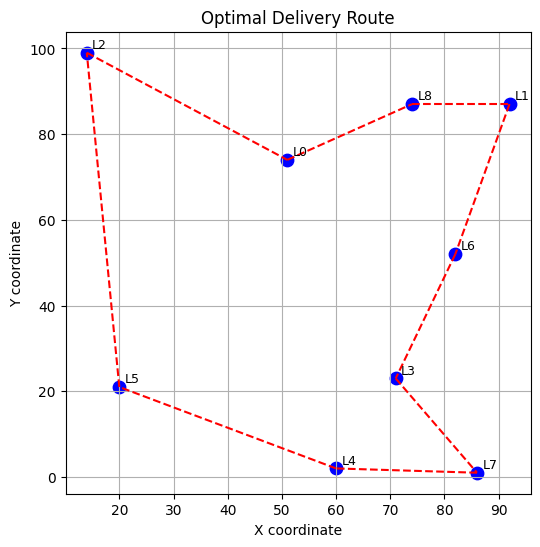

In [7]:
# Extract optimal route
route = ['L0']  # Start at depot. The list route will store the sequence of locations in the optimal route.
current = 'L0' # Holds the nocation we are currently

while True: # This loop repeteadly finds the next location visited from currect and advances current till the route returns to depot
    next_loc = None # Represents next node to visit

    for j in locations_list: # Iterate over all locations to find the next location to visit from current
        if current != j and pulp.value(x.get((current, j), 0)) == 1:
            # x is the dictionary of decision variables created earlier that indicates whether the route goes directly from location i to location j
            # pulp.value(x.get((current, j), 0)) retrieves the value of the decision variable x_(current, j). If this value is 1, it means there is a direct route from current to j
            # Then the confition checks two things: first it avoids loops and in pulp.value(...) == 1 checks wehter the solver set that variable to 1, so the solution uses the edfe from current to j as in the optimal set
            next_loc = j
            break
            # If all confitions are met, the next location, next_loc, is set to j, and the loop breaks, exits the for-loop (first edge after depot is founded and we move to the next step)

    if next_loc is None or next_loc == 'L0':
        break
    # If no next location is found, is None, or the next location is the depor, LO, it breaks the while loop, ending the root building process
    route.append(next_loc) # The next location is added to our route list
    current = next_loc # Then we update current location to be our next location, j before, chosen

route.append('L0')  # Return to depot, completing the tour

print("Optimal Route:")
#print(route)
print(" --> ".join(route))

# Plot the route
plt.figure(figsize=(6,6))
plt.scatter(locations['x'], locations['y'], c='blue', s=80)

# Draw route lines
for i in range(len(route)-1): # Loops over the indices of the route to draw a line between route[i] and route[i+1], the -1 avoinds indexing past the end
    p1 = locations[locations['Location'] == route[i]] # Search in the locations dataframe the row where the location column equals to route[i], in first case, it would be L0
    p2 = locations[locations['Location'] == route[i+1]] # Same but for next location in route
    plt.plot([p1['x'], p2['x']] , [p1['y'], p2['y']], 'r--') # This draw the line that represent the edge

# Label points
for _, row in locations.iterrows(): # Iterates the rows in locations dataframe to label each plotted point in the scatterplot
    plt.text(row['x'] + 1, row['y'] + 1, row['Location'], fontsize=9) # Put location name slightly offset +1,+1; so the text is a little above right the point created

plt.title("Optimal Delivery Route")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid(True)
plt.show()


We can finally see in the plot that our implementation worked and the best optimal route was calculated correctly and there were no errors in the process.